# LOAD DATA

In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Load saved evaluation JSON
# Assuming notebook is in Models/Evaluation and result is in Models/Evaluation/result
RESULTS_PATH = Path.cwd() / "result" / "evaluation_object_result.json"
if not RESULTS_PATH.exists():
    # Fallback to try and find it if CWD is different
    RESULTS_PATH = Path(__file__).parent / "result" / "evaluation_object_result.json" if "__file__" in locals() else Path.cwd() / "result" / "evaluation_object_result.json"

if not RESULTS_PATH.exists():
    print(f"Warning: Results not found at {RESULTS_PATH}")
else:
    with open(RESULTS_PATH, "r", encoding="utf-8") as f:
        raw_results = json.load(f)

    pd.set_option("display.max_rows", 200)
    pd.set_option("display.max_columns", None)
    # Format float display
    pd.options.display.float_format = '{:,.3f}'.format

    flat_df = pd.json_normalize(raw_results)

#### Detection


Detection mAP (per game):


,game,frames,map
15,SNGS-131,750,0.731003
30,SNGS-146,750,0.723879
5,SNGS-121,750,0.700053
23,SNGS-139,750,0.683548
14,SNGS-130,750,0.680286
3,SNGS-119,750,0.652591
11,SNGS-127,750,0.652175
12,SNGS-128,750,0.649996
18,SNGS-134,750,0.622272
24,SNGS-140,750,0.616878


C:\Users\EkmalRey\AppData\Local\Temp\ipykernel_6260\2887180412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=detection_df, x='game', y='map', palette='viridis')


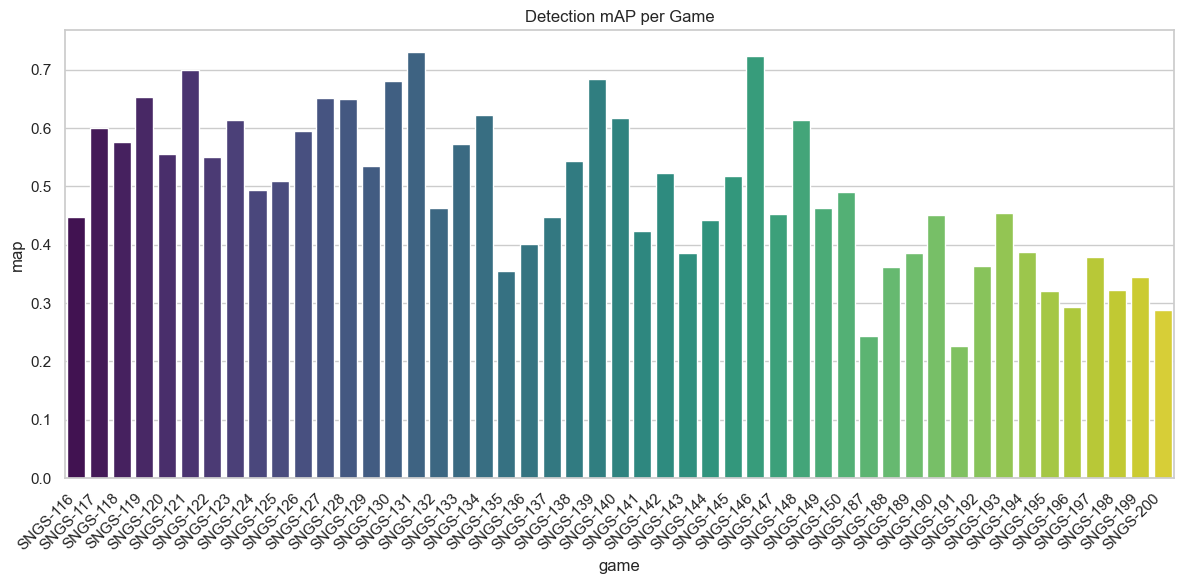


Detection per-class (all games):

Detection per-class summary (mean/median/min/max across games):


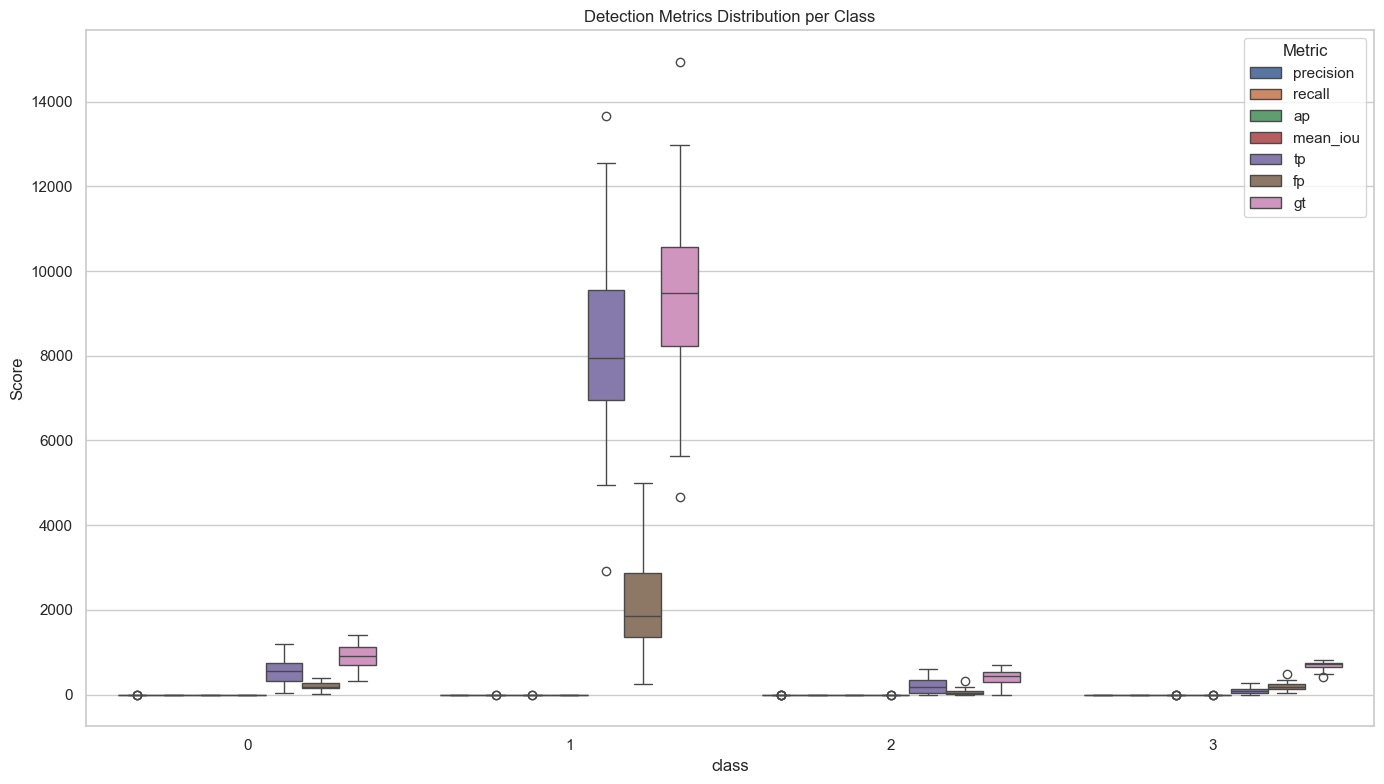

In [14]:
# Detection metrics per game
if "detection.mAP" in flat_df.columns:
    detection_df = flat_df[["game", "frames", "detection.mAP"]].rename(columns={"detection.mAP": "map"})
    print("\nDetection mAP (per game):")
    display(detection_df.sort_values(by='map', ascending=False).style.background_gradient(cmap='viridis', subset=['map']))
    
    # Visualization: mAP per Game
    plt.figure(figsize=(12, 6))
    sns.barplot(data=detection_df, x='game', y='map', palette='viridis')
    plt.title('Detection mAP per Game')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    detection_df = pd.DataFrame()
    print("\nNo detection.mAP found in results.")

# Detection per-class breakdown
per_class_rows = []
for item in raw_results:
    det = item.get("detection", {}) or {}
    per_class = det.get("per_class", {}) or {}
    for cls_id, stats in per_class.items():
        row = {"game": item.get("game"), "frames": item.get("frames"), "class": cls_id}
        if isinstance(stats, dict):
            row.update(stats)
        per_class_rows.append(row)

det_per_class_df = pd.DataFrame(per_class_rows)
if not det_per_class_df.empty:
    metric_candidates = [c for c in det_per_class_df.columns if c not in {"game", "frames", "class"}]
    print("\nDetection per-class (all games):")
    # display(det_per_class_df)

    grouped = det_per_class_df.groupby("class")[metric_candidates].agg(["mean", "median", "min", "max"]).round(3)
    print("\nDetection per-class summary (mean/median/min/max across games):")
    display(grouped.style.background_gradient(cmap='Blues'))
    
    # Visualization: Per-class Metrics
    # Melt for easier plotting with seaborn
    if metric_candidates:
        melted_det = det_per_class_df.melt(id_vars=['game', 'class'], value_vars=metric_candidates, var_name='Metric', value_name='Score')
        
        plt.figure(figsize=(14, 8))
        sns.boxplot(data=melted_det, x='class', y='Score', hue='Metric')
        plt.title('Detection Metrics Distribution per Class')
        plt.tight_layout()
        plt.show()
else:
    print("\nNo detection per-class entries found.")

#### Tracking


Tracking metrics (per game):


,game,frames,idf1,mota,idtp,idfp,idfn,idsw,mt,ml
0,SNGS-116,750,0.827842,0.642827,7814.000000,1514.000000,1736.000000,161.000000,0,0
1,SNGS-117,750,0.854474,0.699660,6312.000000,1117.000000,1033.000000,56.000000,0,1
2,SNGS-118,750,0.837456,0.662662,7414.000000,1553.000000,1325.000000,70.000000,0,2
3,SNGS-119,750,0.869342,0.723903,5915.000000,949.000000,829.000000,84.000000,0,1
4,SNGS-120,750,0.849501,0.692918,8210.000000,1418.000000,1491.000000,70.000000,0,0
5,SNGS-121,750,0.902009,0.799170,8731.000000,988.000000,909.000000,39.000000,0,0
6,SNGS-122,750,0.822123,0.615621,8012.000000,1723.000000,1744.000000,283.000000,0,0
7,SNGS-123,750,0.910981,0.809478,9594.000000,982.000000,893.000000,123.000000,0,0
8,SNGS-124,750,0.800683,0.579326,6327.000000,1699.000000,1451.000000,122.000000,0,0
9,SNGS-125,750,0.819292,0.615198,6039.000000,1294.000000,1370.000000,187.000000,0,0



Tracking summary (mean/median/min/max):


,frames,idf1,mota,idtp,idfp,idfn,idsw,mt,ml
mean,750.000,0.832,0.641,"8,092.755","1,819.449","1,390.694",133.306,0.000,0.245
median,750.000,0.837,0.660,"7,878.000","1,630.000","1,325.000",111.000,0.000,0.000
min,750.000,0.626,0.238,"2,912.000",207.000,180.000,13.000,0.000,0.000
max,750.000,0.985,0.969,"13,622.000","4,238.000","3,538.000",482.000,0.000,4.000


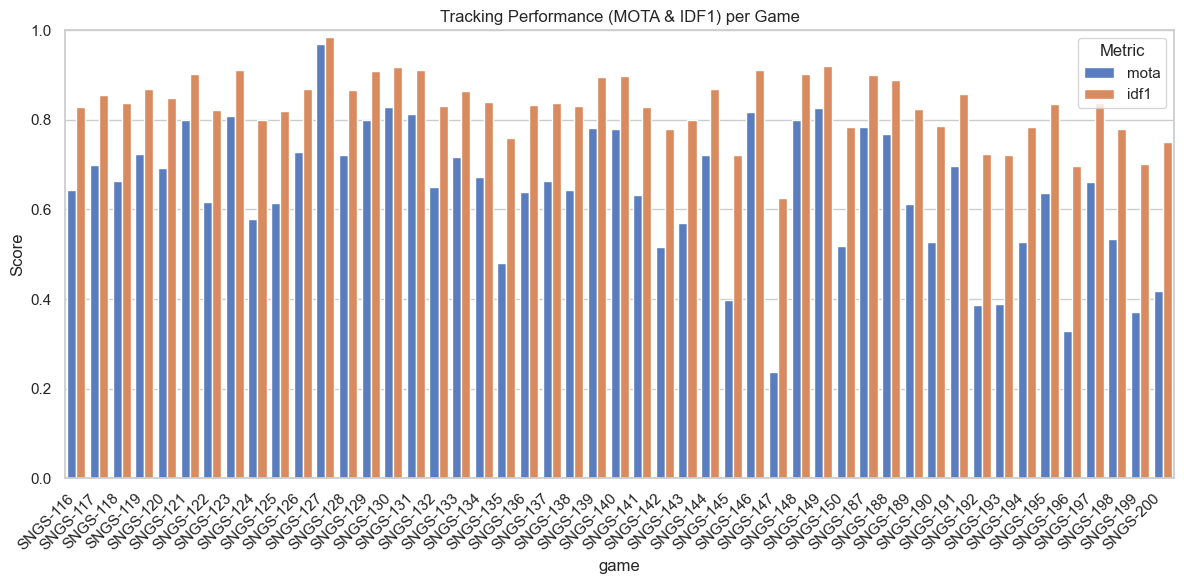

In [15]:
# Tracking metrics table
tracking_cols = [
    "game",
    "frames",
    "tracking.IDF1",
    "tracking.MOTA",
    "tracking.IDTP",
    "tracking.IDFP",
    "tracking.IDFN",
    "tracking.IDSW",
    "tracking.MT",
    "tracking.ML",
]

# Filter columns that actually exist
available_tracking_cols = [c for c in tracking_cols if c in flat_df.columns]

if available_tracking_cols:
    tracking_df = flat_df[available_tracking_cols].rename(columns=lambda c: c.split(".")[-1].lower())
    print("\nTracking metrics (per game):")
    display(tracking_df.style.background_gradient(cmap='RdYlGn', subset=['idf1', 'mota'], vmin=0, vmax=1))

    print("\nTracking summary (mean/median/min/max):")
    summary_tracking = tracking_df.drop(columns=["game"]).agg(["mean", "median", "min", "max"]).round(3)
    display(summary_tracking)
    
    # Visualization: MOTA and IDF1 per Game
    if 'mota' in tracking_df.columns and 'idf1' in tracking_df.columns:
        plt.figure(figsize=(12, 6))
        tracking_melted = tracking_df.melt(id_vars=['game'], value_vars=['mota', 'idf1'], var_name='Metric', value_name='Score')
        sns.barplot(data=tracking_melted, x='game', y='Score', hue='Metric', palette='muted')
        plt.title('Tracking Performance (MOTA & IDF1) per Game')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()
else:
    print("No tracking metrics found.")

#### Clustering


Clustering purity (per game):


,game,frames,purity
0,SNGS-116,750,0.899038
1,SNGS-117,750,0.908152
2,SNGS-118,750,0.928554
3,SNGS-119,750,0.911477
4,SNGS-120,750,0.936750
5,SNGS-121,750,0.932848
6,SNGS-122,750,0.909384
7,SNGS-123,750,0.911352
8,SNGS-124,750,0.895646
9,SNGS-125,750,0.847765



Clustering purity summary:


,frames,purity
mean,750.000,0.942
median,750.000,0.944
min,750.000,0.848
max,750.000,0.982


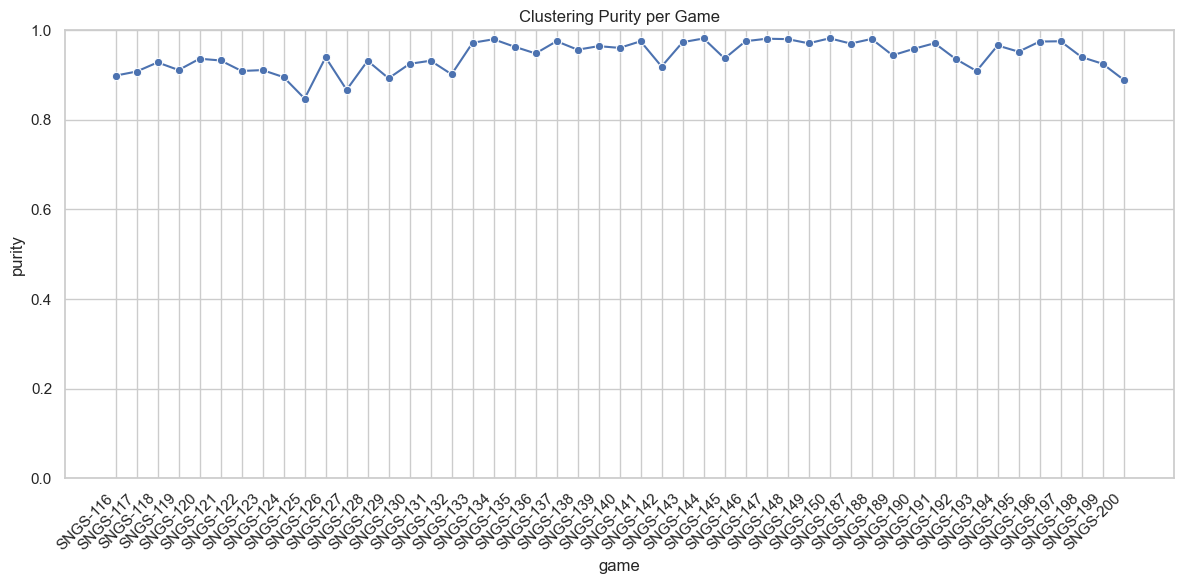

In [16]:
# Clustering purity
if "clustering.purity" in flat_df.columns:
    clustering_df = flat_df[["game", "frames", "clustering.purity"]].rename(columns={"clustering.purity": "purity"})
    print("\nClustering purity (per game):")
    display(clustering_df.style.background_gradient(cmap='Purples', subset=['purity']))

    print("\nClustering purity summary:")
    display(clustering_df.drop(columns=["game"]).agg(["mean", "median", "min", "max"]).round(3))
    
    # Visualization: Purity per Game
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=clustering_df, x='game', y='purity', marker='o', sort=False)
    plt.title('Clustering Purity per Game')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo clustering.purity found in results.")

#### Device Performance


Throughput (per game):


,game,frames,mean_inference_time_s,fps
0,SNGS-116,750,0.021162,47.255020
1,SNGS-117,750,0.020796,48.085179
2,SNGS-118,750,0.021638,46.214930
3,SNGS-119,750,0.020217,49.462307
4,SNGS-120,750,0.022124,45.199831
5,SNGS-121,750,0.021925,45.610622
6,SNGS-122,750,0.022306,44.830050
7,SNGS-123,750,0.022547,44.351939
8,SNGS-124,750,0.021121,47.345554
9,SNGS-125,750,0.020955,47.721612



Throughput summary:


,frames,mean_inference_time_s,fps
mean,750.000,0.023,44.571
median,750.000,0.022,44.497
min,750.000,0.020,40.011
max,750.000,0.025,50.341


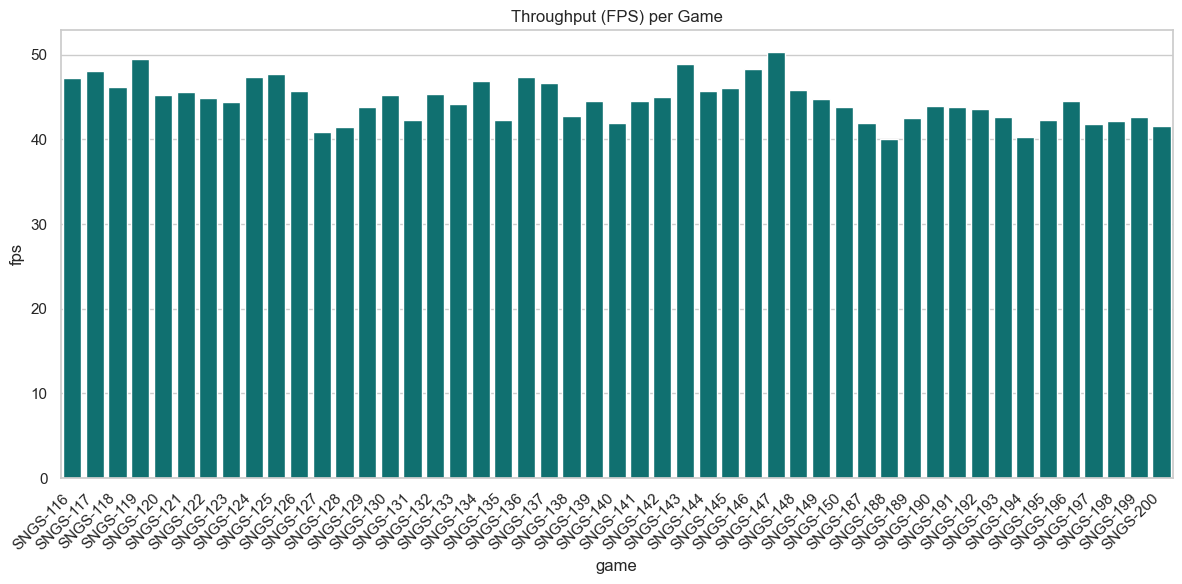

In [17]:
# Throughput metrics
if {"throughput.fps", "throughput.mean_inference_time_s"}.issubset(flat_df.columns):
    throughput_df = flat_df[[
        "game",
        "frames",
        "throughput.mean_inference_time_s",
        "throughput.fps",
    ]].rename(columns={
        "throughput.mean_inference_time_s": "mean_inference_time_s",
        "throughput.fps": "fps",
    })
    print("\nThroughput (per game):")
    display(throughput_df.style.bar(subset=['fps'], color='#5fba7d'))

    print("\nThroughput summary:")
    display(throughput_df.drop(columns=["game"]).agg(["mean", "median", "min", "max"]).round(3))
    
    # Visualization: FPS per Game
    plt.figure(figsize=(12, 6))
    sns.barplot(data=throughput_df, x='game', y='fps', color='teal')
    plt.title('Throughput (FPS) per Game')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\nThroughput metrics not found in results.")

#### Overall Model Summary

In [18]:
# Overall Model Summary
print(f"\nOverall Model Summary (across {len(flat_df)} games):")

overall_metrics = {}

# Detection metrics (averaged across all classes and games)
if 'det_per_class_df' in locals() and not det_per_class_df.empty:
    if "precision" in det_per_class_df.columns:
        overall_metrics["Detection Precision"] = det_per_class_df["precision"].mean()
    if "recall" in det_per_class_df.columns:
        overall_metrics["Detection Recall"] = det_per_class_df["recall"].mean()
    if "ap" in det_per_class_df.columns:
        overall_metrics["Detection mAP (per class avg)"] = det_per_class_df["ap"].mean()
    if "mean_iou" in det_per_class_df.columns:
        overall_metrics["Detection mean IoU (per class avg)"] = det_per_class_df["mean_iou"].mean()
if "detection.mAP" in flat_df.columns:
    overall_metrics["Detection mAP"] = flat_df["detection.mAP"].mean()
if "detection.mean_iou" in flat_df.columns:
    overall_metrics["Detection mean IoU"] = flat_df["detection.mean_iou"].mean()

# Tracking metrics
if "tracking.MOTA" in flat_df.columns:
    overall_metrics["Tracking MOTA"] = flat_df["tracking.MOTA"].mean()
if "tracking.IDF1" in flat_df.columns:
    overall_metrics["Tracking IDF1"] = flat_df["tracking.IDF1"].mean()
if "tracking.MT" in flat_df.columns:
    overall_metrics["Tracking Mostly Tracked"] = flat_df["tracking.MT"].mean()
if "tracking.ML" in flat_df.columns:
    overall_metrics["Tracking Mostly Lost"] = flat_df["tracking.ML"].mean()
if "tracking.IDSW" in flat_df.columns:
    overall_metrics["Tracking ID Switches"] = flat_df["tracking.IDSW"].mean()

# Clustering
if "clustering.purity" in flat_df.columns:
    overall_metrics["Clustering Purity"] = flat_df["clustering.purity"].mean()

# FPS
if "throughput.fps" in flat_df.columns:
    overall_metrics["FPS Average"] = flat_df["throughput.fps"].mean()

if overall_metrics:
    summary_df = pd.DataFrame(list(overall_metrics.items()), columns=["Metric", "Average"])
    summary_df["Average"] = summary_df["Average"].round(3)
    display(summary_df)
else:
    print("No overall metrics found.")


Overall Model Summary (across 49 games):


,Metric,Average
0,Detection Precision,0.614
1,Detection Recall,0.529
2,Detection mAP (per class avg),0.488
3,Detection mean IoU (per class avg),0.717
4,Detection mAP,0.492
5,Detection mean IoU,0.766
6,Tracking MOTA,0.641
7,Tracking IDF1,0.832
8,Tracking Mostly Tracked,0.000
9,Tracking Mostly Lost,0.245


In [19]:
summary_df.to_csv(Path.cwd().parent / "DONE" / "overall_model_summary.csv", index=False)